### Import Libraries

In [1]:
# Imports Básicos
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from scipy import stats # Necessário para a votação majoritária
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Configuração de GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

print("TensorFlow Version:", tf.__version__)

2025-12-15 08:10:53.668187: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-15 08:10:53.715293: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-15 08:10:55.490808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.20.0


### Audio Preprocessing

In [2]:
# Configurações
DATASET_PATH = '../gtzan_dataset/genres_original'
SAMPLE_RATE = 22050
DURATION = 30
SEGMENT_DURATION = 3
SAMPLES_PER_SEGMENT = SAMPLE_RATE * SEGMENT_DURATION
N_MFCC = 128
N_FFT = 2048
HOP_LENGTH = 512

def load_and_preprocess_data(dataset_path):
    data = {"spectrograms": [], "labels": [], "groups": []}
    genres = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    print("Iniciando extração de Mel-Espectogramas...")
    
    track_id_counter = 0 # Identificador único para cada música de 30s
    
    for label_idx, genre in enumerate(genres):
        genre_path = os.path.join(dataset_path, genre)
        print(f"Processando {genre}...")
        
        for file in sorted(os.listdir(genre_path)): # Sorted garante ordem
            file_path = os.path.join(genre_path, file)
            try:
                # Carrega a música inteira
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
                
                # Divide em segmentos
                num_segments = int(DURATION / SEGMENT_DURATION)
                
                for s in range(num_segments):
                    start = SAMPLES_PER_SEGMENT * s
                    finish = start + SAMPLES_PER_SEGMENT
                    
                    if len(signal) >= finish:
                        segment = signal[start:finish]
                        
                        # Extrai Mel-Spectrograma
                        mel_spec = librosa.feature.melspectrogram(
                            y=segment, sr=sr, n_fft=N_FFT, 
                            hop_length=HOP_LENGTH, n_mels=N_MFCC
                        )
                        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
                        
                        # Garante shape (128, 130)
                        if mel_spec_db.shape[1] != 130:
                            if mel_spec_db.shape[1] > 130:
                                mel_spec_db = mel_spec_db[:, :130]
                            else:
                                pad_width = 130 - mel_spec_db.shape[1]
                                mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')

                        data["spectrograms"].append(mel_spec_db)
                        data["labels"].append(label_idx)
                        data["groups"].append(track_id_counter) # ID da música original
                
                track_id_counter += 1
                
            except Exception as e:
                print(f"Erro em {file}: {e}")

    X = np.array(data["spectrograms"])
    # Adiciona canal para CNN (batch, 128, 130, 1)
    X = X[..., np.newaxis] 
    y = np.array(data["labels"])
    groups = np.array(data["groups"])
    
    return X, y, groups, genres

# Executa carregamento
X, y, groups, class_names = load_and_preprocess_data(DATASET_PATH)

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Total de músicas originais (grupos): {len(np.unique(groups))}")

Iniciando extração de Mel-Espectogramas...
Processando blues...
Processando classical...
Processando country...
Processando disco...
Processando hiphop...
Processando jazz...


/tmp/ipykernel_198091/3262609257.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
/home/zurua/miniconda3/envs/tcc_cnn/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Erro em jazz.00054.wav: 
Processando metal...
Processando pop...
Processando reggae...
Processando rock...

Shape de X: (9981, 128, 130, 1)
Shape de y: (9981,)
Total de músicas originais (grupos): 999


### Treino dos Modelos

In [3]:
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential()
    
    # --- Bloco Convolucional 1 ---
    # Tabela 6: 32 filtros
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2)) # Conforme tabela (0.2 a 0.5)

    # --- Bloco Convolucional 2 ---
    # Tabela 6: 64 filtros
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # --- Bloco Convolucional 3 ---
    # Tabela 6: 128 filtros
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))
    
    # --- Bloco Convolucional 4 ---
    # Tabela 6: 256 filtros
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    # --- Classificador (Tabela 6) ---
    # Flatten ou GAP? A tabela menciona GAP (Global Average Pooling)
    model.add(layers.GlobalAveragePooling2D())
    
    # Densa (256) -> Dropout -> Softmax
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-4)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compilação
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

model_test = build_cnn_model((128, 130, 1), 10)
model_test.summary()

/home/zurua/miniconda3/envs/tcc_cnn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1765800705.274519  198091 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 130, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 65, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,882 (4.75 MB)

 Trainable params: 1,241,962 (4.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [4]:
# Configuração do CV
n_splits = 10
gkf = GroupKFold(n_splits=n_splits)

# Listas para armazenar métricas FINAIS (por música)
track_acc_scores = []
history_list = []

# Listas para Matriz de Confusão Global
all_y_true_track = []
all_y_pred_track = []

print(f"Iniciando 10-Fold Cross-Validation (CNN - Frente 3B)...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    
    # Separação dos dados (Segmentos)
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    groups_val = groups[val_idx] # IDs das músicas de validação
    
    # Build do Modelo
    model = build_cnn_model(input_shape=(128, 130, 1), num_classes=len(class_names))
    
    # Callbacks
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
    
    # Treino
    history = model.fit(
        X_train, y_train,
        epochs=70,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=0 # Reduzido para limpar a saída
    )
    history_list.append(history)
    
    # --- AVALIAÇÃO COM VOTAÇÃO MAJORITÁRIA ---
    
    # 1. Previsões nos segmentos
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred_segments = np.argmax(y_pred_probs, axis=1)
    
    # 2. Criar DataFrame para agrupar
    df_eval = pd.DataFrame({
        'group': groups_val,
        'y_true': y_val,
        'y_pred': y_pred_segments
    })
    
    # 3. Votação (Moda) por Grupo (Música)
    # Para cada música (grupo), pegamos a classe mais frequente prevista nos seus segmentos
    track_results = df_eval.groupby('group').agg({
        'y_true': 'first', # O rótulo real é o mesmo para todos os segmentos
        'y_pred': lambda x: stats.mode(x, keepdims=True)[0][0] # Moda das previsões
    })
    
    # 4. Calcular Acurácia por Faixa
    y_true_track = track_results['y_true'].values
    y_pred_track = track_results['y_pred'].values
    
    acc_track = accuracy_score(y_true_track, y_pred_track)
    track_acc_scores.append(acc_track)
    
    # Acumular para matriz de confusão final
    all_y_true_track.extend(y_true_track)
    all_y_pred_track.extend(y_pred_track)
    
    print(f"Acurácia (Segmentos): {np.mean(history.history['val_accuracy'][-5:]):.4f}")
    print(f"Acurácia (Música/Track): {acc_track:.4f} <--- Métrica Oficial")
    
    tf.keras.backend.clear_session()
    import gc
    gc.collect()

print("\n--- Validação Cruzada Concluída ---")

Iniciando 10-Fold Cross-Validation (CNN - Frente 3B)...

--- Fold 1/10 ---


/home/zurua/miniconda3/envs/tcc_cnn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-15 08:11:50.322784: I external/local_xla/xla/service/service.cc:163] XLA service 0x43f80300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-15 08:11:50.322821: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-12-15 08:11:50.407582: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-15 08:11:50.998900: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] L


Epoch 14: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 19: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 9.
Acurácia (Segmentos): 0.8132
Acurácia (Música/Track): 0.8400 <--- Métrica Oficial

--- Fold 2/10 ---


/home/zurua/miniconda3/envs/tcc_cnn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 17: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 12.
Acurácia (Segmentos): 0.8464
Acurácia (Música/Track): 0.9100 <--- Métrica Oficial

--- Fold 3/10 ---


...


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 18: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 23: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 13.
Acurácia (Segmentos): 0.8456
Acurácia (Música/Track): 0.8900 <--- Métrica Oficial

--- Fold 9/10 ---


/home/zurua/miniconda3/envs/tcc_cnn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 20: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 25: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 15.
Acurácia (Segmentos): 0.8468
Acurácia (Música/Track): 0.8900 <--- Métrica Oficial

--- Fold 10/10 ---


/home/zurua/miniconda3/envs/tcc_cnn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-15 09:05:26.880419: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4305', 8 bytes spill stores, 8 bytes spill loads




Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 21: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 16.
Acurácia (Segmentos): 0.8372
Acurácia (Música/Track): 0.8990 <--- Métrica Oficial

--- Validação Cruzada Concluída ---


### Análise de Resultados


=== RESULTADOS FINAIS (Média 10 Folds) ===
Acurácia Média por Música: 0.8769 (+/- 0.0485)


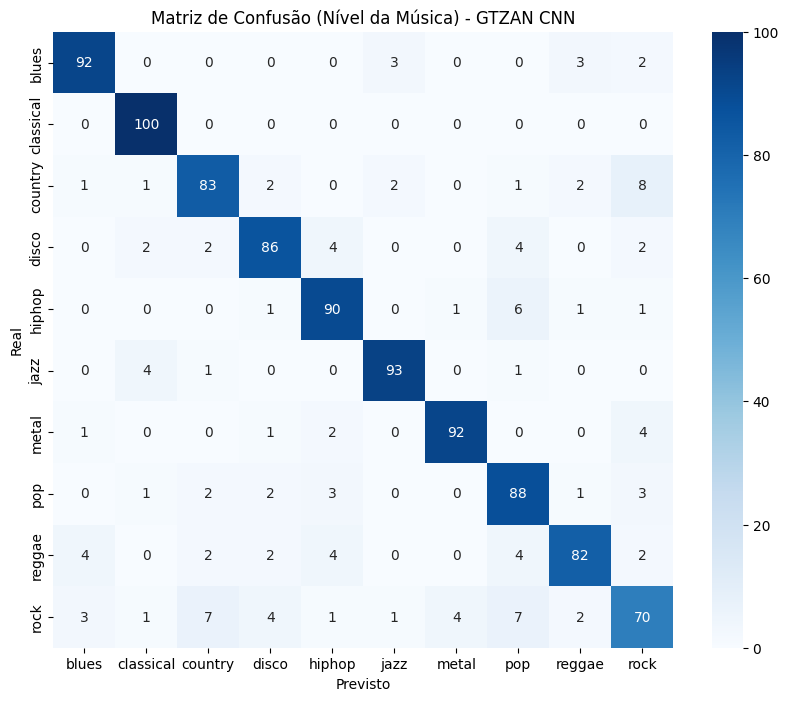


Relatório de Classificação (Por Música):
              precision    recall  f1-score   support

       blues       0.91      0.92      0.92       100
   classical       0.92      1.00      0.96       100
     country       0.86      0.83      0.84       100
       disco       0.88      0.86      0.87       100
      hiphop       0.87      0.90      0.88       100
        jazz       0.94      0.94      0.94        99
       metal       0.95      0.92      0.93       100
         pop       0.79      0.88      0.83       100
      reggae       0.90      0.82      0.86       100
        rock       0.76      0.70      0.73       100

    accuracy                           0.88       999
   macro avg       0.88      0.88      0.88       999
weighted avg       0.88      0.88      0.88       999



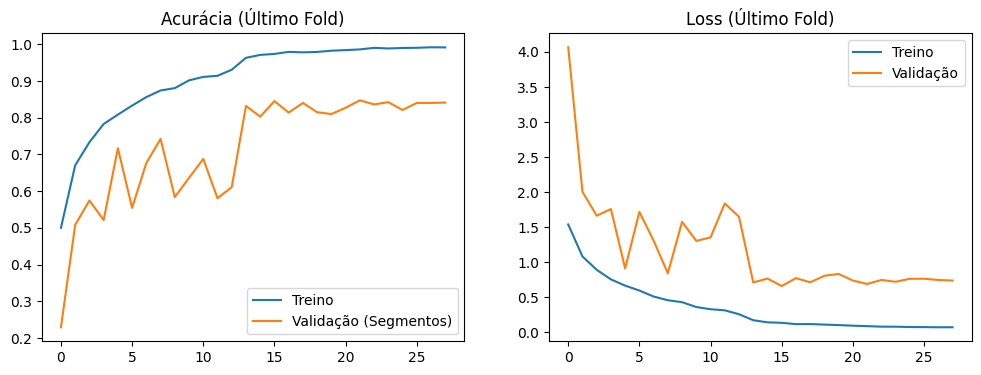

In [5]:
# Resultados Consolidados
print(f"\n=== RESULTADOS FINAIS (Média 10 Folds) ===")
print(f"Acurácia Média por Música: {np.mean(track_acc_scores):.4f} (+/- {np.std(track_acc_scores):.4f})")

# Matriz de Confusão
cm = confusion_matrix(all_y_true_track, all_y_pred_track)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão (Nível da Música) - GTZAN CNN')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# Relatório Completo
print("\nRelatório de Classificação (Por Música):")
print(classification_report(all_y_true_track, all_y_pred_track, target_names=class_names))

# Curvas de Aprendizado (Do último fold como exemplo)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_list[-1].history['accuracy'], label='Treino')
plt.plot(history_list[-1].history['val_accuracy'], label='Validação (Segmentos)')
plt.title('Acurácia (Último Fold)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_list[-1].history['loss'], label='Treino')
plt.plot(history_list[-1].history['val_loss'], label='Validação')
plt.title('Loss (Último Fold)')
plt.legend()
plt.show()